### Lab 5.1: Convolutional Neural Networks in PyTorch

In this lab you will explore how to create a convolutional neural network (CNN) with PyTorch.

The CNN will run slowly unless you have an accelerator (like on newer MacBooks or in Google Colab).  On Colab, make sure to select the GPU runtime in `Runtime > Change runtime type`.

Here I load the Intel Image Classification dataset.  The images have been resized to 32x32.

In [4]:
!wget -q -nc -O intel_image_classification.npz "https://www.dropbox.com/scl/fi/g8piaiw6njhogb7fnu7b3/intel_image_classification.npz?rlkey=8ytc0ucpc7tg2gzs0gxtnzun5&dl=1"

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
import numpy as np
from matplotlib import pyplot as plt

In [6]:
data = np.load('intel_image_classification.npz')
label_names = data['label_names']
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

The dataset has six categories and around 16k images total.

In [7]:
label_names

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype='<U9')

In [8]:
X_train.shape, X_train.dtype, X_train.min(), X_train.max()

((13986, 32, 32, 3), dtype('float32'), np.float32(0.0), np.float32(1.0))

In [9]:
y_train.shape, y_train.dtype, y_train.min(), y_train.max()

((13986,), dtype('int64'), np.int64(0), np.int64(5))

In [10]:
len(X_train), len(X_test)

(13986, 2993)

Text(0.5, 1.0, '0')

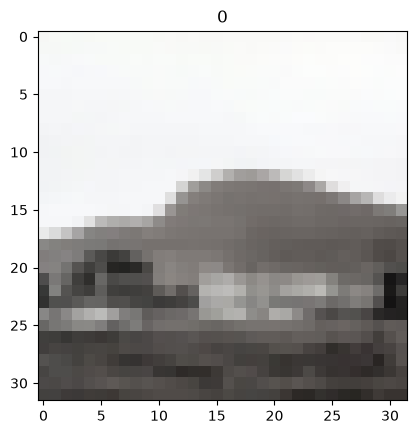

In [11]:
plt.imshow(X_train[0])
plt.title(y_train[0])

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [13]:
X_train_torch = torch.tensor(X_train.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_train_torch = torch.tensor(y_train)
X_test_torch = torch.tensor(X_test.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_test_torch = torch.tensor(y_test)

## Exercises

Create a CNN to classify the images.  Here is a starting point for your architecture, although you are free to put whatever you want into the network:

* Input layer
* 2D convolution, 3x3 kernel, 32 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 64 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 128 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* Flatten
* Linear layer: 6 outputs

Choose some settings for the optimizer etc. and see what accuracy can you achieve on this dataset.

In [14]:
train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch), batch_size=32, shuffle=True)    
test_loader = DataLoader(TensorDataset(X_test_torch, y_test_torch), batch_size=32, shuffle=False)

class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.linear1 = nn.Linear(128 * 4 * 4, 512)
        self.linear2 = nn.Linear(512, len(label_names))

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.linear1(x))
        x = self.linear2(x)
        return x


model = ImageClassifier()
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs.float())
        loss_value = loss(outputs, labels)
        loss_value.backward()
        optimizer.step()
        running_loss += loss_value.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}")

# evaluate accuracy using test loader
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.float())
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test set: {100 * correct / total:.2f}%")



Epoch 1/10, Loss: 1.0586174488339795
Epoch 2/10, Loss: 0.7815327593316771
Epoch 3/10, Loss: 0.6805217332763759
Epoch 4/10, Loss: 0.5944903181295961
Epoch 5/10, Loss: 0.53486410142284
Epoch 6/10, Loss: 0.4616135268314788
Epoch 7/10, Loss: 0.4011187810263677
Epoch 8/10, Loss: 0.33771427472964033
Epoch 9/10, Loss: 0.27788870891802797
Epoch 10/10, Loss: 0.21847061553893432
Accuracy on test set: 78.68%
